### Pré-processamento dos arquivos parquet:

1. Adicionando a coluna de bairro (Borough) a partir do arquivo "taxi_zone_lookup.csv"

2. Removendo coluna "ehail_fee" que não aparece no dicionário de dados e contém somente valores nulos

3. Adicionando outras outras colunas desejadas para análise

In [1]:
import pandas as pd
import os
import glob
import matplotlib.pyplot as plt

In [2]:
# Configurações

# Caminho da pasta onde estão os arquivos parquet originais a serem pré-processados
PASTA_ENTRADA = '../data/green'

# Caminho do arquivo CSV contendo a relação entre LocationID e Borough (bairro)
ARQUIVO_CSV = '../data/taxi_zone_lookup.csv'

# Pasta onde o arquivo processado que será criado
PASTA_ARQUIVO_PROCESSADO = '../data/parquet_processado'

# Nome do novo arquivo processado que será criado
NOME_ARQUIVO_PROCESSADO = 'green_tripdata_2023.parquet'

CAMINHO_ARQUIVO_PROCESSADO = PASTA_ARQUIVO_PROCESSADO + "/" + NOME_ARQUIVO_PROCESSADO

In [3]:
# 1. Cria a pasta de saída caso ela ainda não exista
if not os.path.exists(PASTA_ARQUIVO_PROCESSADO):
    os.makedirs(PASTA_ARQUIVO_PROCESSADO)
    print(f"Pasta de saída '{PASTA_ARQUIVO_PROCESSADO}' criada.")

print(f"Carregando o arquivo de bairros: {ARQUIVO_CSV}...")
# 2. Carrega o CSV contendo os bairros
try:
    df_zonas = pd.read_csv(ARQUIVO_CSV)[['LocationID', 'Borough']]
except FileNotFoundError:
    print(f"Erro: O arquivo '{ARQUIVO_CSV}' não foi encontrado.")

Carregando o arquivo de bairros: ../data/taxi_zone_lookup.csv...


In [4]:
# 3. Busca todos os arquivos .parquet na pasta de entrada
padrao_busca = os.path.join(PASTA_ENTRADA, '*.parquet')
arquivos_parquet = glob.glob(padrao_busca)

if not arquivos_parquet:
    print(f"Nenhum arquivo parquet encontrado na pasta '{PASTA_ENTRADA}'.")
else:
    print(f"Encontrados {len(arquivos_parquet)} arquivo(s) Parquet. Iniciando processamento...")

    df_viagens_completo = pd.DataFrame()
    # 4. Loop por cada arquivo encontrado
    for caminho_arquivo in arquivos_parquet:
        nome_arquivo = os.path.basename(caminho_arquivo)

        # Lê o parquet atual
        df_viagens = pd.read_parquet(caminho_arquivo)

        # Remove coluna inválida
        df_viagens.drop(columns=['ehail_fee'], inplace=True)

        # Merge de Embarque (PULocationID)
        df_viagens = df_viagens.merge(
            df_zonas,
            how='left',
            left_on='PULocationID',
            right_on='LocationID'
        )
        df_viagens.rename(columns={'Borough': 'pu_borough'}, inplace=True)
        df_viagens.drop(columns=['LocationID'], inplace=True)

        # Merge de Desembarque (DOLocationID)
        df_viagens = df_viagens.merge(
            df_zonas,
            how='left',
            left_on='DOLocationID',
            right_on='LocationID'
        )
        df_viagens.rename(columns={'Borough': 'do_borough'}, inplace=True)
        df_viagens.drop(columns=['LocationID'], inplace=True)

        # Preenche o valor N/A nas colunas de bairro com NaN
        # O valor N/A é previsto e significa que o bairro não foi identificado
        # Após o merge, por algum motivo os N/A se tornam NaN
        df_viagens['pu_borough'] = df_viagens['pu_borough'].fillna('N/A')
        df_viagens['do_borough'] = df_viagens['do_borough'].fillna('N/A')

        df_viagens_completo = pd.concat([df_viagens_completo, df_viagens])
print("Arquivos parquet processados!")

Encontrados 12 arquivo(s) Parquet. Iniciando processamento...
Arquivos parquet processados!


### Adicionando novas colunas para análise de custo

In [5]:
# 1. Calculando 'fare_per_mile'
# Evita divisão por zero: se trip_distance for 0, fare_per_mile será 0.
df_viagens_completo['fare_per_mile'] = df_viagens_completo.apply(
    lambda row: row['fare_amount'] / row['trip_distance'] if row['trip_distance'] > 0 else 0,
    axis=1
)

# 2. Calculando 'fare_per_minute'
# Calcula a duração da viagem em minutos
df_viagens_completo['trip_duration_minutes'] = (df_viagens_completo['lpep_dropoff_datetime'] - df_viagens_completo['lpep_pickup_datetime']).dt.total_seconds() / 60

# Garante que trip_duration_minutes seja sempre maior que zero
df_viagens_completo['trip_duration_minutes'] = df_viagens_completo['trip_duration_minutes'].apply(lambda x: x if x > 0 else 0)

# Evita divisão por zero para trip_duration_minutes
df_viagens_completo['fare_per_minute'] = df_viagens_completo.apply(
    lambda row: row['fare_amount'] / row['trip_duration_minutes'] if row['trip_duration_minutes'] > 0 else 0,
    axis=1
)

# Exibindo as primeiras linhas com as novas colunas
display(df_viagens_completo[['fare_amount', 'trip_distance', 'fare_per_mile', 'lpep_pickup_datetime', 'lpep_dropoff_datetime', 'trip_duration_minutes', 'fare_per_minute']].head())

,fare_amount,trip_distance,fare_per_mile,lpep_pickup_datetime,lpep_dropoff_datetime,trip_duration_minutes,fare_per_minute
0,14.9,2.58,5.775194,2023-01-01 00:26:10,2023-01-01 00:37:11,11.016667,1.352496
1,10.7,1.81,5.911602,2023-01-01 00:51:03,2023-01-01 00:57:49,6.766667,1.581281
2,7.2,0.00,0.000000,2023-01-01 00:35:12,2023-01-01 00:41:32,6.333333,1.136842
3,6.5,1.30,5.000000,2023-01-01 00:13:14,2023-01-01 00:19:03,5.816667,1.117479
4,6.0,1.10,5.454545,2023-01-01 00:33:04,2023-01-01 00:39:02,5.966667,1.005587


Analisando dados do arquivo resultante

In [6]:
df_viagens_completo.describe(include = "all")

,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,store_and_fwd_flag,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,...,improvement_surcharge,total_amount,payment_type,trip_type,congestion_surcharge,pu_borough,do_borough,fare_per_mile,trip_duration_minutes,fare_per_minute
count,787060.000000,787060,787060,731447,731447.000000,787060.000000,787060.000000,731447.000000,787060.000000,787060.000000,...,787060.000000,787060.000000,731447.000000,731402.000000,731447.000000,787060,787060,787060.000000,787060.000000,787060.000000
unique,NaN,NaN,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,8,8,NaN,NaN,NaN
top,NaN,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,Manhattan,Manhattan,NaN,NaN,NaN
freq,NaN,NaN,NaN,728661,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,446368,451407,NaN,NaN,NaN
mean,1.869004,2023-06-29 06:31:26.038536,2023-06-29 06:51:01.762349,NaN,1.166675,98.320908,139.379558,1.293438,19.020025,18.330881,...,0.976781,23.856761,1.353192,1.035292,0.742594,NaN,NaN,12.177932,19.595397,8.109996
min,1.000000,2008-12-31 22:41:41,2008-12-31 23:01:41,NaN,1.000000,1.000000,1.000000,0.000000,0.000000,-500.000000,...,-1.000000,-501.000000,1.000000,1.000000,-2.750000,NaN,NaN,-22508.000000,0.000000,-2550.000000
25%,2.000000,2023-03-28 15:26:58.250000,2023-03-28 15:45:17.750000,NaN,1.000000,74.000000,74.000000,1.000000,1.150000,9.300000,...,1.000000,13.500000,1.000000,1.000000,0.000000,NaN,NaN,5.294118,7.529167,1.035230
50%,2.000000,2023-06-25 11:29:55,2023-06-25 11:43:01,NaN,1.000000,75.000000,138.000000,1.000000,1.920000,14.200000,...,1.000000,18.900000,1.000000,1.000000,0.000000,NaN,NaN,6.545455,11.983333,1.180328
75%,2.000000,2023-09-29 17:10:53,2023-09-29 17:37:07,NaN,1.000000,129.000000,223.000000,1.000000,3.470000,21.200000,...,1.000000,28.100000,2.000000,1.000000,2.750000,NaN,NaN,7.948718,18.783333,1.402597
max,2.000000,2023-12-31 23:59:19,2024-01-01 14:56:28,NaN,99.000000,265.000000,265.000000,9.000000,278990.280000,4003.000000,...,1.000000,4004.500000,5.000000,2.000000,2.750000,NaN,NaN,49900.000000,1439.916667,34311.428571


In [7]:
df_viagens_completo.info()

<class 'pandas.DataFrame'>
Index: 787060 entries, 0 to 64214
Data columns (total 24 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   VendorID               787060 non-null  int64         
 1   lpep_pickup_datetime   787060 non-null  datetime64[us]
 2   lpep_dropoff_datetime  787060 non-null  datetime64[us]
 3   store_and_fwd_flag     731447 non-null  str           
 4   RatecodeID             731447 non-null  float64       
 5   PULocationID           787060 non-null  int64         
 6   DOLocationID           787060 non-null  int64         
 7   passenger_count        731447 non-null  float64       
 8   trip_distance          787060 non-null  float64       
 9   fare_amount            787060 non-null  float64       
 10  extra                  787060 non-null  float64       
 11  mta_tax                787060 non-null  float64       
 12  tip_amount             787060 non-null  float64       
 13  t

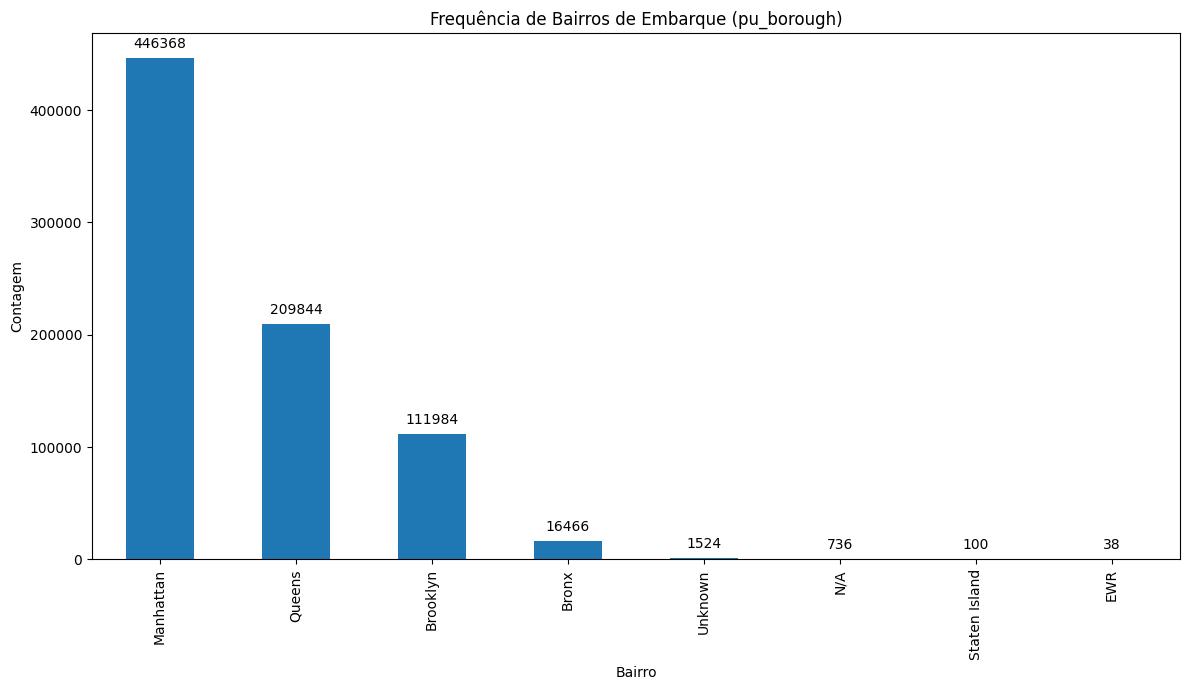

In [8]:
# Verificando corretude dos dados de bairro
# Para plotar dados categóricos, precisamos contar a frequência de cada categoria

# Plot para 'pu_borough' (pickup borough)
plt.figure(figsize=(12, 7))
ax1 = df_viagens_completo['pu_borough'].value_counts().plot(kind='bar', title='Frequência de Bairros de Embarque (pu_borough)')
plt.ylabel('Contagem')
plt.xlabel('Bairro')

# Adiciona os valores nas barras
for p in ax1.patches:
    ax1.annotate(f'{p.get_height():.0f}',
                 (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='bottom',
                 xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.show()

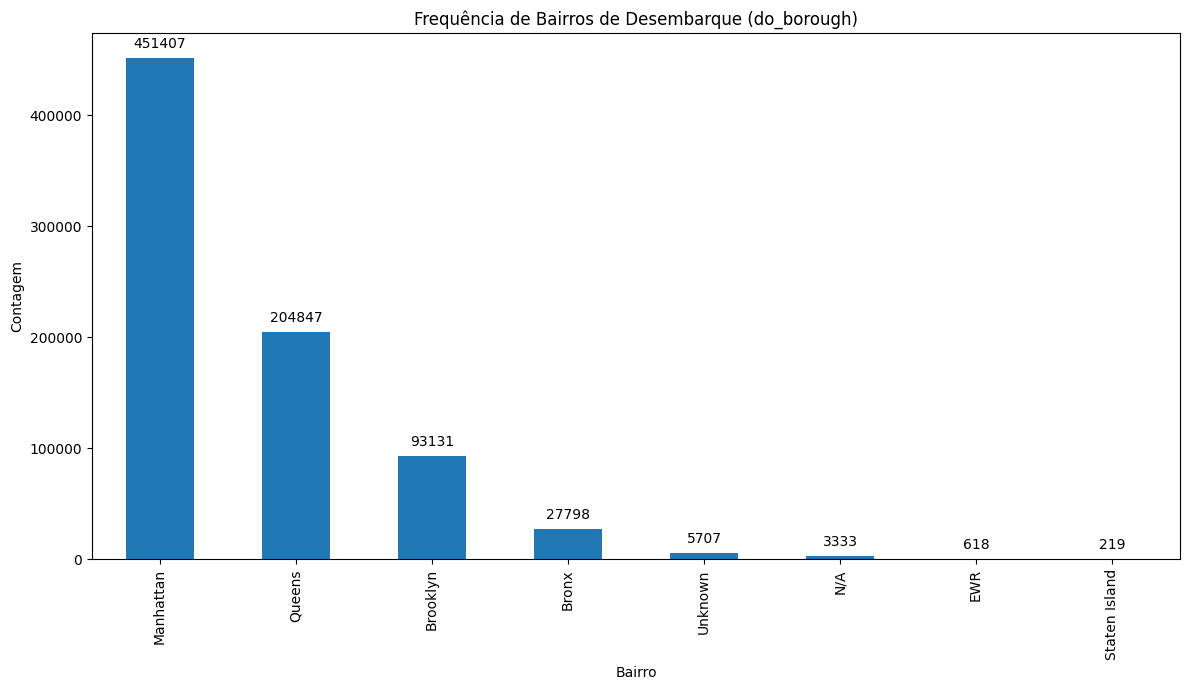

In [9]:
# Plot para 'do_borough' (dropoff borough)
plt.figure(figsize=(12, 7))
ax2 = df_viagens_completo['do_borough'].value_counts().plot(kind='bar', title='Frequência de Bairros de Desembarque (do_borough)')
plt.ylabel('Contagem')
plt.xlabel('Bairro')

# Adiciona os valores nas barras
for p in ax2.patches:
    ax2.annotate(f'{p.get_height():.0f}',
                 (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='bottom',
                 xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.show()

### Calculando fare_per_minute médio por bairro

In [10]:
fare_per_minute_by_borough = df_viagens_completo.groupby('pu_borough')['fare_per_minute'].mean().reset_index()
fare_per_minute_by_borough.rename(columns={'fare_per_minute': 'average_fare_per_minute'}, inplace=True)
display(fare_per_minute_by_borough.sort_values(by='average_fare_per_minute', ascending=False))

,pu_borough,average_fare_per_minute
2,EWR,777.635764
7,Unknown,452.544816
4,N/A,270.238223
6,Staten Island,257.162354
0,Bronx,14.476268
5,Queens,13.186667
1,Brooklyn,12.033731
3,Manhattan,2.433237


### Calculando fare_per_mile médio por bairro

In [11]:
fare_per_mile_by_borough = df_viagens_completo.groupby('pu_borough')['fare_per_mile'].mean().reset_index()
fare_per_mile_by_borough.rename(columns={'fare_per_mile': 'average_fare_per_mile'}, inplace=True)
display(fare_per_mile_by_borough.sort_values(by='average_fare_per_mile', ascending=False))

,pu_borough,average_fare_per_mile
2,EWR,559.517083
6,Staten Island,143.328426
7,Unknown,118.668782
4,N/A,47.915823
1,Brooklyn,16.055112
5,Queens,15.544104
0,Bronx,13.975018
3,Manhattan,9.057966


### Limpeza de dados

In [12]:
print(f"Shape do DataFrame antes da remoção: {df_viagens_completo.shape}")

# 1) Remover trip_duration_minutes <= 1 e >= 120 minutos
df_viagens_completo = df_viagens_completo[
    (df_viagens_completo['trip_duration_minutes'] > 1) &
    (df_viagens_completo['trip_duration_minutes'] < 120)
]

# 2) Remover trip_distance <= 0.1 e >= 50 milhas
df_viagens_completo = df_viagens_completo[
    (df_viagens_completo['trip_distance'] > 0.1) &
    (df_viagens_completo['trip_distance'] < 50)
]

# 3) Remover fare_amount <= 2.5 dólares
df_viagens_completo = df_viagens_completo[df_viagens_completo['fare_amount'] > 2.5]

print(f"Shape do DataFrame depois da remoção: {df_viagens_completo.shape}")

Shape do DataFrame antes da remoção: (787060, 24)
Shape do DataFrame depois da remoção: (732121, 24)


### Recalculando fare_per_minute médio por bairro após limpeza


In [13]:
fare_per_minute_by_borough = df_viagens_completo.groupby('pu_borough')['fare_per_minute'].mean().reset_index()
fare_per_minute_by_borough.rename(columns={'fare_per_minute': 'average_fare_per_minute'}, inplace=True)
display(fare_per_minute_by_borough.sort_values(by='average_fare_per_minute', ascending=False))

,pu_borough,average_fare_per_minute
2,EWR,8.182619
4,N/A,2.643305
7,Unknown,1.855792
6,Staten Island,1.415126
5,Queens,1.370578
0,Bronx,1.329560
1,Brooklyn,1.266554
3,Manhattan,1.260114


### Recalculando fare_per_mile médio por bairro após limpeza


In [14]:
fare_per_mile_by_borough = df_viagens_completo.groupby('pu_borough')['fare_per_mile'].mean().reset_index()
fare_per_mile_by_borough.rename(columns={'fare_per_mile': 'average_fare_per_mile'}, inplace=True)
display(fare_per_mile_by_borough.sort_values(by='average_fare_per_mile', ascending=False))

,pu_borough,average_fare_per_mile
2,EWR,25.324786
4,N/A,11.486214
7,Unknown,11.206013
1,Brooklyn,7.608472
5,Queens,7.424515
3,Manhattan,7.229013
0,Bronx,7.008450
6,Staten Island,6.574066


### Salvando resultado para arquivo parquet

In [15]:
# Salva o resultado
df_viagens_completo.to_parquet(CAMINHO_ARQUIVO_PROCESSADO, index=False)
print(f"   Salvo com sucesso em: {CAMINHO_ARQUIVO_PROCESSADO}")

   Salvo com sucesso em: ../data/parquet_processado/green_tripdata_2023.parquet
